In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import re
import sklearn
from sklearn.model_selection import train_test_split

In [8]:
df = pd.read_csv('/content/Womens Clothing E-Commerce Reviews.csv')
df = df.drop(['Unnamed: 0'], axis=1)
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [9]:
#Visible nulls. Get count of all nulls in each column
df.isnull().sum()

Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [10]:
#Replace string nulls with empty string
df['Title'] = df['Title'].fillna('')
df['Review Text'] = df['Review Text'].fillna('')
df['Division Name'] = df['Division Name'].fillna('')
df['Department Name'] = df['Department Name'].fillna('')
df['Class Name'] = df['Class Name'].fillna('')
df.isnull().sum()

Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64

In [13]:
#concatenate title, review text, division name, department name, and clas name as new feature called reviews
df['Reviews'] = df['Title'] + ' ' + df['Review Text'] + ' ' + df['Division Name'] + ' ' + df['Department Name'] + ' ' + df['Class Name']
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Reviews
0,767,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Absolutely wonderful - silky and sexy and com...
1,1080,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Love this dress! it's sooo pretty. i happen...
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Some major design flaws I had such high hopes ...
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,"My favorite buy! I love, love, love this jumps..."
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Flattering shirt This shirt is very flattering...


In [14]:
#Need to use same RE expression as module to clean the code
df['Reviews'] = df['Reviews'].apply(lambda x: re.sub('[^A-Za-z0-9]+', ' ', x))
df['Reviews'] = df['Reviews'].apply(lambda x: re.sub(r'\b[a-zA-Z]{1,2}\b', '', x))
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Reviews
0,767,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Absolutely wonderful silky and sexy and comfo...
1,1080,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Love this dress sooo pretty happened find...
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Some major design flaws had such high hopes f...
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,favorite buy love love love this jumpsuit ...
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Flattering shirt This shirt very flattering ...


In [15]:
#Split the data into training and test sets
X = df['Reviews'].values
y = df['Recommended IND'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
print(f'X_train size  ={X_train.shape}; X_test size  ={X_test.shape}')

X_train size  =(18788,); X_test size  =(4698,)


In [16]:
#Convert text to numerical values like the module shows
# Specify the vocab size
VOCAB_SIZE = 1000
# Perform textvectorization
encoder = tf.keras.layers.experimental.preprocessing.TextVectorization(
    max_tokens=VOCAB_SIZE)

# Fits the state of the preprocessing layer to the dataset.
encoder.adapt(X_train)

In [18]:
#Build the model
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=64,
        # Use masking to handle the variable sequence lengths
        mask_zero=True),
    tf.keras.layers.GRU(128, return_sequences=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [19]:
#Compile the model
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(.001),
              metrics=['accuracy'])

In [20]:
%%time
 history = model.fit(X_train, y_train, batch_size=32, epochs=5, validation_data=(X_test,y_test),verbose=1)

Epoch 1/5
588/588 [==============================] - 353s 577ms/step - loss: 0.2628 - accuracy: 0.8786 - val_loss: 0.2289 - val_accuracy: 0.9049
Epoch 2/5
588/588 [==============================] - 299s 508ms/step - loss: 0.2044 - accuracy: 0.9098 - val_loss: 0.2353 - val_accuracy: 0.9066
Epoch 3/5
588/588 [==============================] - 295s 501ms/step - loss: 0.1898 - accuracy: 0.9174 - val_loss: 0.2335 - val_accuracy: 0.9051
Epoch 4/5
588/588 [==============================] - 292s 498ms/step - loss: 0.1827 - accuracy: 0.9217 - val_loss: 0.2296 - val_accuracy: 0.8955
Epoch 5/5
588/588 [==============================] - 294s 501ms/step - loss: 0.1697 - accuracy: 0.9276 - val_loss: 0.2325 - val_accuracy: 0.8925
CPU times: user 37min 9s, sys: 1min 53s, total: 39min 2s
Wall time: 25min 34s


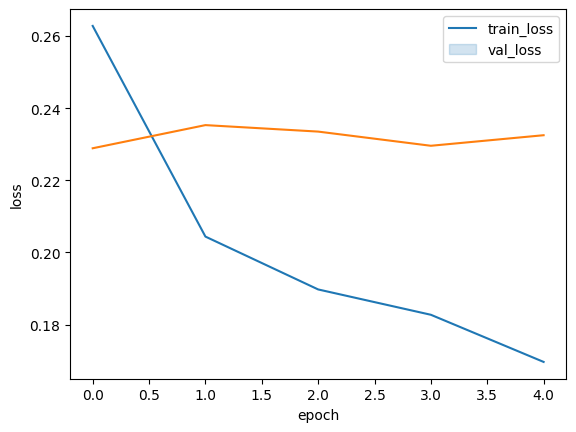

In [21]:
#visualize the results
train_history = pd.DataFrame(history.history)
train_history['epoch'] = history.epoch
# Plot train loss
sns.lineplot(x='epoch', y ='loss', data =train_history)
# Plot validation loss
sns.lineplot(x='epoch', y ='val_loss', data =train_history)
# Add legends
plt.legend(labels=['train_loss', 'val_loss'])

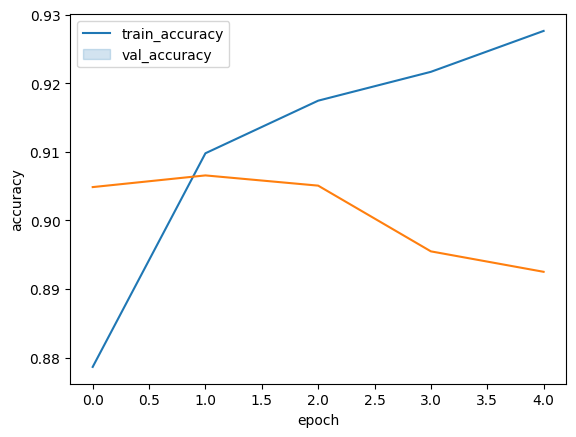

In [22]:
sns.lineplot(x='epoch', y ='accuracy', data =train_history)
# Plot validation loss
sns.lineplot(x='epoch', y ='val_accuracy', data =train_history)
# Add legends
plt.legend(labels=['train_accuracy', 'val_accuracy'])

In [23]:
#evaluate the model
y_pred = (model.predict(X_test)> 0.5).astype(int)
print(sklearn.metrics.confusion_matrix(y_test, y_pred))
print(sklearn.metrics.classification_report(y_test, y_pred))

147/147 [==============================] - 25s 143ms/step
[[ 666  169]
 [ 336 3527]]
              precision    recall  f1-score   support

           0       0.66      0.80      0.73       835
           1       0.95      0.91      0.93      3863

    accuracy                           0.89      4698
   macro avg       0.81      0.86      0.83      4698
weighted avg       0.90      0.89      0.90      4698



# Results

I would recommend this model because it does not appear to underfit and has a relatively great accuracy on unseen data.